<a href="https://colab.research.google.com/github/xiny87/healthcare-python-practice/blob/main/Hospital_Readmission_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Readmission Exploratory Data Analysis

Author: Xin Anne Yuan  
Tools: Python, pandas, Google Colab  

This notebook performs a basic exploratory data analysis (EDA) on a simulated hospital dataset.  
The goal is to understand patient characteristics and examine potential patterns in hospital readmission.

Tools used:
- Python
- pandas
- basic statistical summaries

## 1. Data Preparation

First, we import the necessary Python libraries and create a simulated dataset representing hospital visits.

The dataset contains the following variables:

- patient_id: unique identifier for each patient
- age: patient age
- gender: patient gender
- visit_date: hospital visit date
- readmitted: whether the patient was readmitted (1 = yes, 0 = no)

In [4]:
import pandas as pd
import numpy as np

data = {
    "patient_id": [1,2,3,4,5,6,7,8,9,10],
    "age": [45,62,37,50,29,70,41,56,33,60],
    "gender": ["Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
    "visit_date": [
        "2024-01-05","2024-02-10","2024-03-12","2024-01-20","2024-04-18",
        "2024-02-25","2024-03-30","2024-01-15","2024-04-02","2024-02-08"
    ],
    "readmitted": [0,1,0,0,1,1,0,0,1,0]
}

df = pd.DataFrame(data)
df

,patient_id,age,gender,visit_date,readmitted
0,1,45,Female,2024-01-05,0
1,2,62,Male,2024-02-10,1
2,3,37,Female,2024-03-12,0
3,4,50,Male,2024-01-20,0
4,5,29,Female,2024-04-18,1
5,6,70,Male,2024-02-25,1
6,7,41,Female,2024-03-30,0
7,8,56,Male,2024-01-15,0
8,9,33,Female,2024-04-02,1
9,10,60,Male,2024-02-08,0


In [5]:
df.to_csv("data.csv", index=False)

## 2. Data Preview

We first inspect the first few rows of the dataset to understand the structure and verify that the data was loaded correctly.

In [6]:
df.head(5)

,patient_id,age,gender,visit_date,readmitted
0,1,45,Female,2024-01-05,0
1,2,62,Male,2024-02-10,1
2,3,37,Female,2024-03-12,0
3,4,50,Male,2024-01-20,0
4,5,29,Female,2024-04-18,1


## 3. Data Structure

Next, we examine the structure of the dataset, including the data types and number of observations.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  10 non-null     int64 
 1   age         10 non-null     int64 
 2   gender      10 non-null     object
 3   visit_date  10 non-null     object
 4   readmitted  10 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 532.0+ bytes


## 4. Summary Statistics

We generate descriptive statistics for numerical variables to understand the distribution of patient age and other numerical features.

In [8]:
df.describe()

,patient_id,age,readmitted
count,10.00000,10.00000,10.000000
mean,5.50000,48.30000,0.400000
std,3.02765,13.56507,0.516398
min,1.00000,29.00000,0.000000
25%,3.25000,38.00000,0.000000
50%,5.50000,47.50000,0.000000
75%,7.75000,59.00000,1.000000
max,10.00000,70.00000,1.000000


In [9]:
df["visit_date"] = pd.to_datetime(df["visit_date"])

## 5. Missing Data Check

Checking for missing values is an important step in data analysis.  
Here we count the number of missing values in each column.

In [10]:
df.isna().sum()

,0
patient_id,0
age,0
gender,0
visit_date,0
readmitted,0


## 6. Average Age by Gender

We calculate the average age of patients grouped by gender to explore demographic differences.

In [11]:
df.groupby("gender")["age"].mean()

,age
gender,
Female,37.0
Male,59.6


## 7. Readmission Distribution

Next, we examine how many patients were readmitted versus not readmitted.

In [12]:
df.groupby("readmitted").size()

,0
readmitted,
0,6
1,4


## 8. Sorting by Visit Date

We sort the dataset by visit date to identify the most recent hospital visits.

In [13]:
df.sort_values("visit_date",ascending=False)

,patient_id,age,gender,visit_date,readmitted
4,5,29,Female,2024-04-18,1
8,9,33,Female,2024-04-02,1
6,7,41,Female,2024-03-30,0
2,3,37,Female,2024-03-12,0
5,6,70,Male,2024-02-25,1
1,2,62,Male,2024-02-10,1
9,10,60,Male,2024-02-08,0
3,4,50,Male,2024-01-20,0
7,8,56,Male,2024-01-15,0
0,1,45,Female,2024-01-05,0


In [14]:
df.loc[df["age"]>50]

,patient_id,age,gender,visit_date,readmitted
1,2,62,Male,2024-02-10,1
5,6,70,Male,2024-02-25,1
7,8,56,Male,2024-01-15,0
9,10,60,Male,2024-02-08,0


In [15]:
df["readmitted"].mean()

np.float64(0.4)

In [16]:
df.loc[(df["gender"]=="Female") & (df["age"]>50)]

,patient_id,age,gender,visit_date,readmitted


In [17]:
df.groupby("gender")["readmitted"].mean()

,readmitted
gender,
Female,0.4
Male,0.4


In [18]:
df.groupby("gender")["readmitted"].agg(["mean","count"])

,mean,count
gender,,
Female,0.4,5
Male,0.4,5


## 9. Filtering Patients

We identify patients who are older than 50 years old and were readmitted.  
This type of filtering can help identify higher-risk patient groups.

In [19]:
df[(df["readmitted"]==1) & (df["age"]>50)]

,patient_id,age,gender,visit_date,readmitted
1,2,62,Male,2024-02-10,1
5,6,70,Male,2024-02-25,1


## 10. Readmission by Gender

A contingency table is used to compare readmission counts across genders.

In [20]:
pd.crosstab(df["gender"],df["readmitted"])

readmitted,0,1
gender,,
Female,3,2
Male,3,2


## Data Visualization

To better understand the dataset, we create simple visualizations
to explore patient age distribution and hospital readmission patterns.

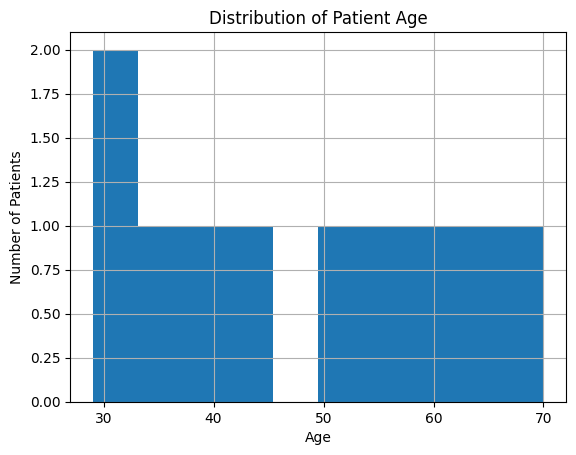

In [21]:
import matplotlib.pyplot as plt

df["age"].hist()

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

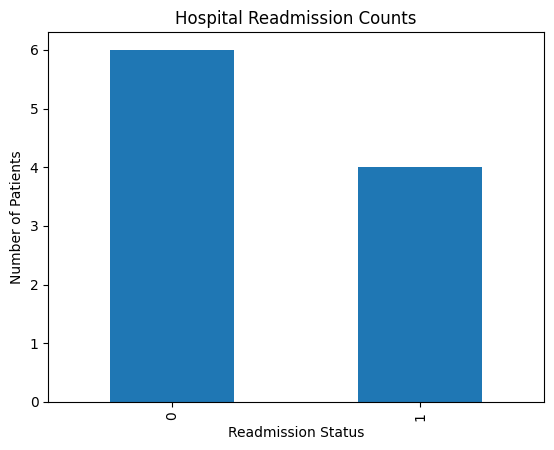

In [22]:
df["readmitted"].value_counts().plot(kind="bar")

plt.title("Hospital Readmission Counts")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.show()

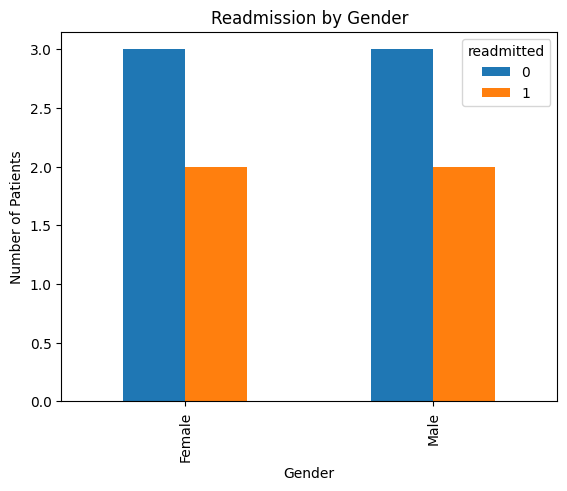

In [23]:
pd.crosstab(df["gender"], df["readmitted"]).plot(kind="bar")

plt.title("Readmission by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

## Conclusion

In this notebook, we performed a basic exploratory data analysis on a simulated hospital dataset.

Key steps included:

- Inspecting the dataset structure
- Checking missing values
- Computing summary statistics
- Exploring demographic patterns
- Examining hospital readmission patterns

These steps form the foundation of many real-world healthcare data science workflows.